In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq

In [5]:
baseline_incidence = 0.03
death_rate = 1/9 # (1 / duration)
medcare_g = 0.0128
drug_prev_reduction = 0.35

def implied_lambda_prime(lambda0=baseline_incidence,
                         delta=death_rate,
                         g=medcare_g,
                         r=1- drug_prev_reduction,
                         t=5,
                         S0=1,
                         I0=None):
    """
    Return λ' such that I_treat(t) = r * I_control(t)
    under the growth-with-fatality model (1)–(3).
    
    Units: rates in 1/yr, t in yr, S0 and I0 are population sizes
           (or proportions) at t = 0.
    """
    if I0 is None:                 # user left I0 unspecified
        I0 = 1.0 - S0              # start with same sized susceptible pool,
                                   # rest infected
    def I(t, lam):
        denom = g - lam + delta
        return np.exp(-delta*t) * (
            I0 + lam*S0*(np.exp((g - lam + delta)*t) - 1.0)/denom
        )
    f = lambda lam_p: I(t, lam_p) - r*I(t, lambda0)
    return brentq(f, a=1e-8, b=lambda0)   # λ' must be < λ0 to get a reduction

In [6]:
lam_prime = implied_lambda_prime(t=10)
print(f"Implied incidence with drug: {lam_prime:.4f}")
pct_reduction = (baseline_incidence - lam_prime) / baseline_incidence * 100
print(f"Percentage reduction in incidence: {pct_reduction:.1f}%")


Implied incidence with drug: 0.0182
Percentage reduction in incidence: 39.3%


In [7]:
records = []
for t in range(1, 25):
  lam_prime = implied_lambda_prime(t=t)
  pct_reduction = (baseline_incidence - lam_prime) / baseline_incidence * 100
  records.append({
    'year': t,
    'implied_incidence': lam_prime,
    'pct_reduction': pct_reduction
	})
  
records = pd.DataFrame(records)

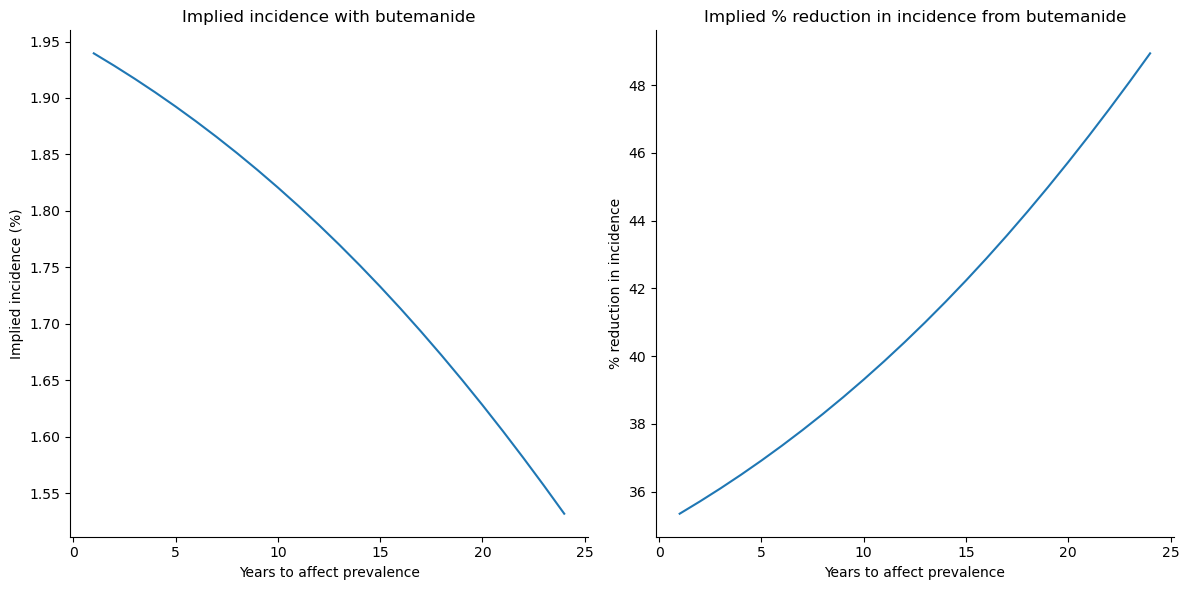

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(records['year'], records['implied_incidence'] * 100)
ax1.set_xlabel("Years to affect prevalence")
ax1.set_ylabel("Implied incidence (%)")
ax1.set_title("Implied incidence with butemanide")
ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(records['year'], records['pct_reduction'])
ax2.set_xlabel("Years to affect prevalence")
ax2.set_ylabel("% reduction in incidence")
ax2.set_title("Implied % reduction in incidence from butemanide")
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()